# Annual GDP Growth and Debt of the 27 EU-countries

We look at the annual gdp growth and debt of the current 27 EU-countries for the period from 2000 until 2022. 
The data set for the annual gdp growth is from the World Bank and directly contains the current 27 EU-countries and the period from 2000 until 2022. It can be downloaded here: https://databank.worldbank.org/reports.aspx?source=2&series=NY.GDP.MKTP.KD.ZG&country=#.
The data set for the annual debt comes from Danmarks Statistics and can be downloaded here: 
https://www.statbank.dk/20172. The debt is given in € (Mill. Euro (current prices)).

Here we import the relevant packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets # for interactive plots/buttons
from collections import Counter

plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})
# user written modules
#import dataproject


# Read and clean data

We downloaded both data sets and saved them as xlsx. Therefore, we load the data first.

First the data for the annual gdp growth (in %):

In [2]:
filename_world_bank_update = 'gdp_growth_world_bank_update.xlsx'
gdp_world_bank = pd.read_excel(filename_world_bank_update)
gdp_world_bank.head(5)

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Austria,AUT,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Belgium,BEL,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Greece,GRC,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Italy,ITA,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Lithuania,LTU,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


Then we load the second data set containing the annual debt:

In [3]:
filename_debt = 'new_debt_data.xlsx'

# removing 2 irrelevant rows
debt = pd.read_excel(filename_debt, skiprows=2)
debt.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,2000,2001,2002,2003,2004,2005,2006,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Mill. Euro (current prices),Government EMU-debt,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,NaN,NaN,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,NaN,NaN,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,NaN,NaN,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,NaN,NaN,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


By looking at the initial data sets we see that both are in a wide data format. 
For both data sets we need to do some data cleaning. 
For example, we saw that the column headers have two rows in the gdp data set. However, we would like to delete the second row such that there is only one row for the header. There also some unnecessary columns in the current gdp data set (for example Series Code or Country Code). These will be deleted. 

In [4]:
## data cleaning for the first data set
## delete irrelevant columns
del gdp_world_bank["Series Code"]
del gdp_world_bank["Country Code"]
gdp_world_bank.head(5)


# Removing the part in brackets
gdp_world_bank.columns = [name.split(' [')[0] for name in gdp_world_bank.columns]
gdp_world_bank.head(5)

## rename variables 
gdp_world_bank.rename(columns = {'Series Name':'Variable'}, inplace=True)
gdp_world_bank.rename(columns = {'Country Name':'Countries'}, inplace=True)



For the debt data set, we do similar data cleaning: We remove the first two columns and rename the column containing the 27 countries.

In [5]:
# removing 2 columns
debt = debt.iloc[:, 2:]

# renaming
debt.rename(columns = {'Unnamed: 2':'Countries'}, inplace=True)

# Renaming countries to match debt dataset with gdp dataset
country_renames = {
    'Slovakia': 'Slovak Republic',
    'Czech Republic': 'Czechia'
}
debt['Countries'] = debt['Countries'].replace(country_renames)

The cleaned data sets look like these: 

In [6]:
gdp_world_bank.head(5)

,Variable,Countries,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,GDP growth (annual %),Austria,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,3.454042,3.727415,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),Belgium,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,2.552350,3.676881,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),Greece,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,5.652434,3.273747,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),Italy,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,1.790640,1.487073,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),Lithuania,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,7.414121,11.107480,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


In [7]:
debt.head(5)

,Countries,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,300063.7,327683.2,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,5296.9,4848.6,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,9461.9,8658.6,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,63755.0,80547.5,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,617.5,749.4,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


In the following we change the data format from wide to long. Especially for the later merge of both data frames, it makes more sense to have the data sets in long format.

In [8]:
# from wide to long
gdp_growth_long = pd.melt(gdp_world_bank, id_vars=['Countries'], value_vars = ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
                                                                                '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020','2021','2022'],
var_name='year', value_name='annual_gdp_growth')

# changing index from (0,1,2...) to countries
#gdp_growth_long = gdp_growth_long.set_index('Countries')

gdp_growth_long.head(5)

,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525


In [9]:
# wide to long
debt_long = pd.melt(debt, id_vars=['Countries'], var_name='year', value_name='debt')
debt_long.head(5)

# changing index from (0,1,2...) to countries
#debt_long = debt_long.set_index('Countries')

debt_long.head(5)

,Countries,year,debt
0,Belgium,2000,280959.5
1,Bulgaria,2000,10177.1
2,Cyprus,2000,6024.5
3,Denmark,2000,93084.0
4,Estonia,2000,315.6


## Exploring data sets

We know look at summary statistics of both data sets. Since we have both data formats, we are also able to look at a summary across countries to compare different years in the wide format. This can be helpful to identify outlier-years.

In [10]:
## summary statistic of gdp growth for the wide format: 
## get a summary statistic for the wide format for each year across different countries 
description_gdp_wide = gdp_world_bank.describe()
description_gdp_wide


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,...,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,5.130061,3.045232,3.197920,3.209616,4.373774,4.004903,5.180710,5.136779,1.347001,-5.352893,...,0.286484,2.205493,3.653492,2.580062,3.962905,3.383565,2.965571,-4.354673,7.215687,3.855848
std,3.467922,1.834668,2.255573,2.791392,2.281927,2.656944,2.465906,2.831966,3.109683,3.972067,...,2.177185,2.273906,4.593814,1.265638,2.383059,2.009536,1.655607,3.639918,2.884774,2.193676
min,1.166527,-1.174697,-0.197974,-0.930521,0.140269,0.599142,1.625034,0.277373,-5.132001,-14.838608,...,-6.553078,-1.829309,-0.196088,-0.487173,1.092149,0.925811,0.483198,-11.167298,2.838180,-1.287411
25%,3.706102,1.812570,1.610705,0.989727,2.782437,2.282901,3.638715,3.356484,-0.317674,-6.145852,...,-0.722224,0.870819,1.822533,2.004461,2.624078,1.907544,1.861231,-7.086725,5.942231,2.447467
50%,4.001029,3.074355,2.730948,2.960260,4.336856,3.506835,4.713829,5.075022,0.959879,-4.657331,...,0.437591,1.902173,2.342591,2.518828,3.192410,2.820323,2.682760,-3.886084,6.844522,3.724549
75%,5.460843,4.013324,5.222139,4.655702,5.169937,5.296393,6.449035,7.020848,3.098127,-3.293048,...,1.181195,2.889763,3.861889,3.096669,4.977699,4.242378,3.944176,-2.389739,8.120981,5.159247
max,19.681269,6.526109,7.088129,10.565957,10.428113,10.720366,11.971836,11.107480,9.307467,2.832184,...,5.473356,8.828999,24.475253,6.454554,10.869269,8.470295,7.058727,6.617195,15.125220,9.433022


In [11]:
descripton_debt_wide = debt.describe()
descripton_debt_wide

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,...,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01
mean,1.935240e+05,2.002349e+05,2.070149e+05,2.165488e+05,2.275294e+05,2.377860e+05,2.434668e+05,2.477750e+05,2.669535e+05,2.971351e+05,...,3.788675e+05,3.883111e+05,3.936111e+05,4.004164e+05,4.050799e+05,4.086630e+05,4.120407e+05,4.573346e+05,4.821909e+05,4.998471e+05
std,3.672209e+05,3.780732e+05,3.898513e+05,4.105146e+05,4.298885e+05,4.503465e+05,4.634989e+05,4.712226e+05,4.957783e+05,5.408636e+05,...,6.582775e+05,6.729476e+05,6.804660e+05,6.932865e+05,7.027566e+05,7.106377e+05,7.196171e+05,7.925658e+05,8.375858e+05,8.674273e+05
min,3.156000e+02,3.334000e+02,4.429000e+02,4.897000e+02,4.999000e+02,5.331000e+02,6.281000e+02,6.175000e+02,7.494000e+02,1.023100e+03,...,1.934200e+03,2.129900e+03,2.077400e+03,2.174100e+03,2.174000e+03,2.127400e+03,2.373400e+03,5.094400e+03,5.533500e+03,6.657400e+03
25%,6.778650e+03,8.161100e+03,8.115050e+03,8.155650e+03,8.291050e+03,8.643000e+03,8.899600e+03,8.737750e+03,8.460550e+03,1.132825e+04,...,2.211330e+04,2.461685e+04,2.569210e+04,2.569375e+04,2.541430e+04,2.679510e+04,2.665915e+04,3.140620e+04,3.181160e+04,3.345700e+04
50%,3.949400e+04,4.096920e+04,4.198740e+04,4.340930e+04,5.050510e+04,5.407560e+04,6.229880e+04,6.375500e+04,7.331730e+04,8.020000e+04,...,1.139434e+05,1.178014e+05,1.085324e+05,1.054501e+05,1.057270e+05,1.025973e+05,1.041876e+05,1.318597e+05,1.235391e+05,1.344690e+05
75%,1.447312e+05,1.550626e+05,1.613530e+05,1.670990e+05,1.786337e+05,1.941898e+05,2.030000e+05,2.122948e+05,2.332925e+05,2.655383e+05,...,2.918638e+05,2.998150e+05,3.019968e+05,3.056282e+05,3.037162e+05,3.100714e+05,3.058422e+05,3.287845e+05,3.440660e+05,3.536477e+05
max,1.353569e+06,1.420027e+06,1.436142e+06,1.471326e+06,1.526400e+06,1.591581e+06,1.657334e+06,1.677650e+06,1.738647e+06,1.839233e+06,...,2.201918e+06,2.203743e+06,2.239410e+06,2.285705e+06,2.329932e+06,2.381640e+06,2.410323e+06,2.657352e+06,2.823692e+06,2.949331e+06


Using the summary statistics we could plot the time series of the dispersion of annual gdp growth and debt: 

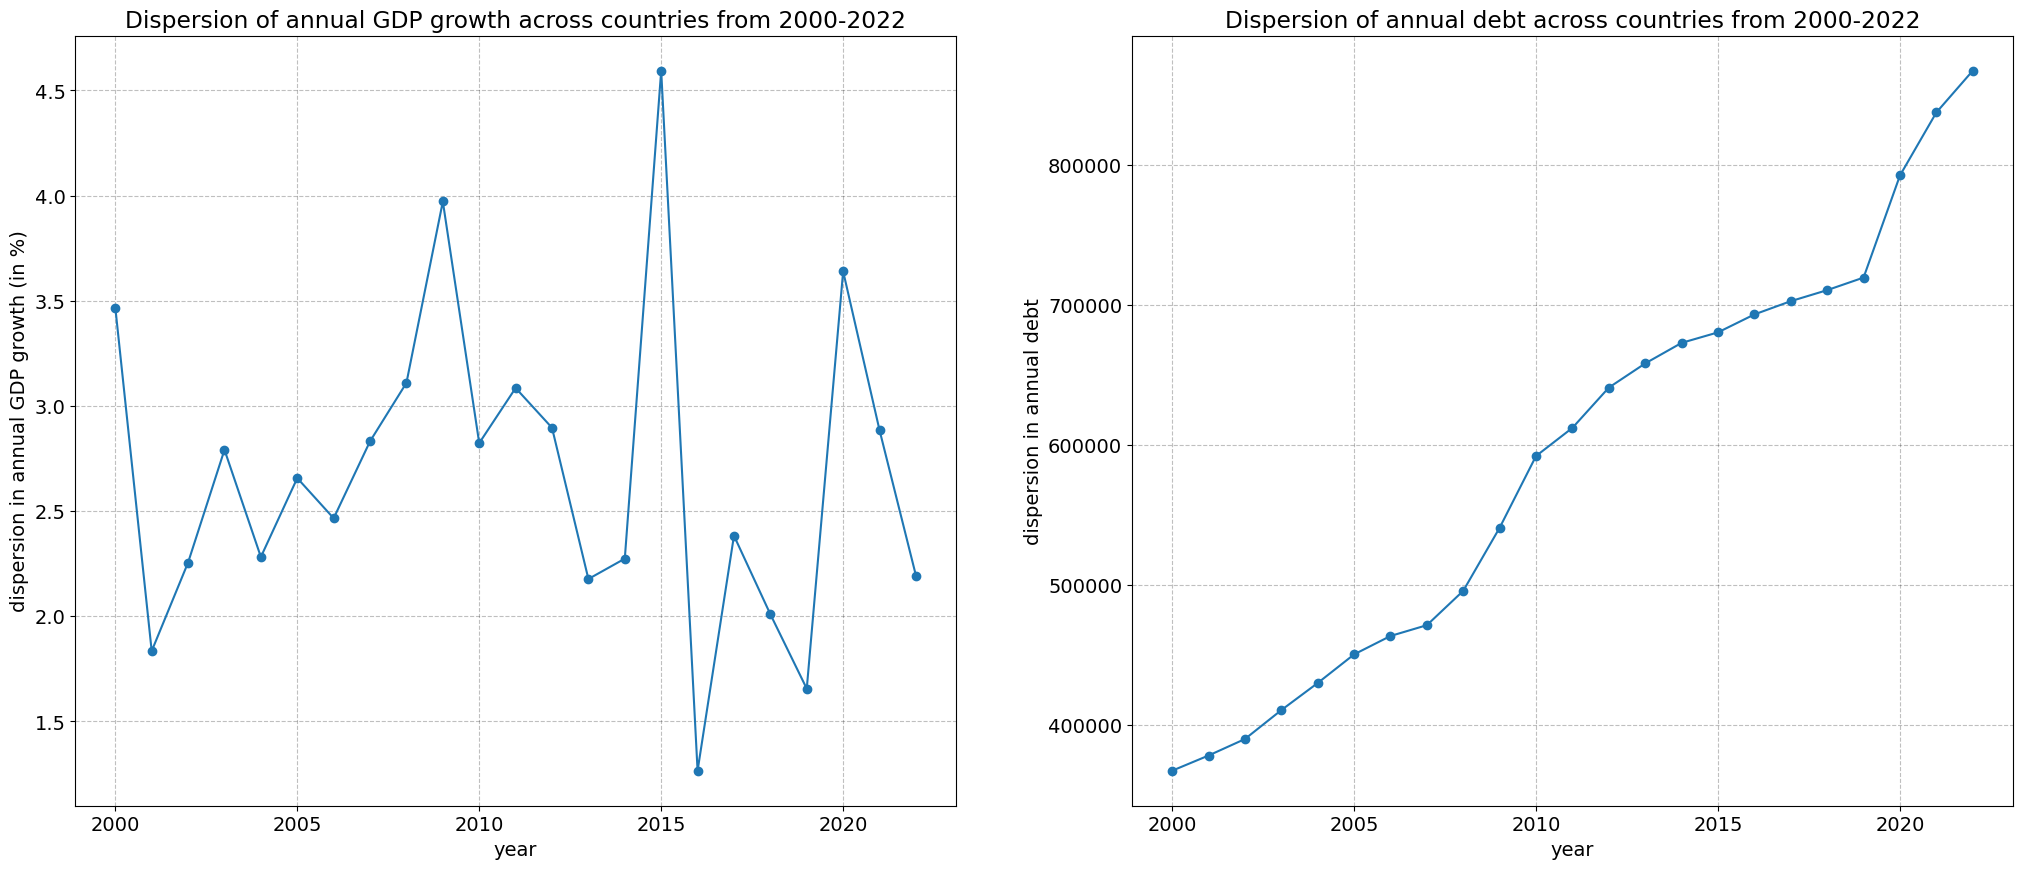

In [12]:

## plotting yearly dispersion across countries
fig = plt.figure(frameon=True,figsize=(25,10), dpi=100)
ax = fig.add_subplot(1,2,1)

## plot dispersion 
description_gdp_wide.loc["std"].plot(ax=ax,style='-o')
#ax.legend(bbox_to_anchor=(0.185, 0.18))
ax.set_xlabel('year')
#plt.xticks(rotation=45)
ax.set_ylabel('dispersion in annual GDP growth (in %)')
ax.set_title('Dispersion of annual GDP growth across countries from 2000-2022')


## plotting yearly dispersion across countries
az = fig.add_subplot(1,2,2)

#ax.plot(gdp_growth['year'], gdp_growth['year_sd_gdp_growth'])
descripton_debt_wide.loc["std"].plot(ax=az,style='-o')
#ax.legend(bbox_to_anchor=(0.185, 0.18))
az.set_xlabel('year')
#plt.xticks(rotation=45)
az.set_ylabel('dispersion in annual debt')
az.set_title('Dispersion of annual debt across countries from 2000-2022')
plt.show();


HERE WE NEED TO DESCRIBE THE TWO PLOTS!!
There is a trend in the dispersion of annual debt across countries. Whereas, the GDP growth fluctuates more. 

Using the data sets in long format, we can create interactive plots to look at the annual gdp growth and debt of each country over time: 

In [13]:
# This function tells the widget how the plot should look at a specific parametrization 
def interactive_figure(country):
    # Create a figure
    fig = plt.figure(frameon=True,figsize=(30,12), dpi=100)
    ax = fig.add_subplot(1,2,1)
    
    # Plot the selected country's GDP growth time series
    selected_country_data = gdp_growth_long[gdp_growth_long['Countries'] == country]
    ax.plot(selected_country_data['year'], selected_country_data['annual_gdp_growth'])
    
    # Set the title
    ax.set_xlabel('year')
    plt.xticks(rotation=45)
    ax.set_ylabel('annual gdp growth (in %)')
    ax.set_title("Time Series of GDP Growth for {}".format(country))


    az = fig.add_subplot(1,2,2)
    
    # Plot the selected country's debt time series
    selected_country_data = debt_long[debt_long['Countries'] == country]
    az.plot(selected_country_data['year'], selected_country_data['debt'])
    
    # Set the title
    az.set_xlabel('year')
    plt.xticks(rotation=45)
    az.set_ylabel('annual gdp growth (in %)')
    az.set_title("Time Series of debt for {}".format(country))
    
    # Show the plot
    plt.show()

In [14]:
# Define the list of countries for which we want to have a drop down 
countries = list(gdp_world_bank['Countries'])

In [15]:
# Create the dropdown widget
# semikolon avoids additional text to be printed 
widgets.interact(interactive_figure, country=countries);

interactive(children=(Dropdown(description='country', options=('Austria', 'Belgium', 'Greece', 'Italy', 'Lithu…

We see that in general the GDP growth is fluctuating for most of the countries over the years. Whereas the time series of debt has an upward trend for most of the countries. 

We can also add summmary statistics for the data in long format:

In [16]:
# Sorting the countries together
gdp_growth_long_sort = gdp_growth_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
gdp_growth_mean = gdp_growth_long_sort.groupby('Countries')['annual_gdp_growth'].mean().rename('country_mean_gdp_growth')

# Joining the mean gdp growth back to the original dataframe
gdp_growth_long = gdp_growth_long_sort.join(gdp_growth_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
gdp_growth_long['gdp_mean_dev'] = gdp_growth_long['annual_gdp_growth'] - gdp_growth_long['country_mean_gdp_growth']

gdp_growth_long.head(30)

,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev
0,Austria,2000,3.375722,1.511706,1.864016
27,Austria,2001,1.267168,1.511706,-0.244538
54,Austria,2002,1.651554,1.511706,0.139847
81,Austria,2003,0.941471,1.511706,-0.570236
108,Austria,2004,2.735120,1.511706,1.223414
135,Austria,2005,2.244065,1.511706,0.732359
162,Austria,2006,3.454042,1.511706,1.942335
189,Austria,2007,3.727415,1.511706,2.215709
216,Austria,2008,1.460424,1.511706,-0.051283
243,Austria,2009,-3.764578,1.511706,-5.276285


In [17]:
# Sorting the countries together
debt_long_sort = debt_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
debt_mean = debt_long_sort.groupby('Countries')['debt'].mean().rename('country_mean_debt')

# Joining the mean gdp growth back to the original dataframe
debt_long = debt_long_sort.join(debt_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
debt_long['debt_mean_dev'] = debt_long['debt'] - debt_long['country_mean_debt']

debt_long.head(30)

,Countries,year,debt,country_mean_debt,debt_mean_dev
26,Austria,2000,141245.5,237894.756522,-96649.256522
53,Austria,2001,147154.2,237894.756522,-90740.556522
80,Austria,2002,151295.9,237894.756522,-86598.856522
107,Austria,2003,152688.1,237894.756522,-85206.656522
134,Austria,2004,157985.4,237894.756522,-79909.356522
161,Austria,2005,174403.5,237894.756522,-63491.256522
188,Austria,2006,180270.0,237894.756522,-57624.756522
215,Austria,2007,184674.5,237894.756522,-53220.256522
242,Austria,2008,201809.9,237894.756522,-36084.856522
269,Austria,2009,230014.6,237894.756522,-7880.156522


Another idea would be to look which country had the highest/lowest gdp_growth or debt for each year. We will define a function that does this for us!

We start by exploring the annual GDP growth: 

In [37]:
def find_country_with_extreme_value_per_year(data, column_name):
    """
    Find the country with the highest and lowest value for the specified column for each year in the given DataFrame.
    Also count how often each country appears as the country with the minimum and maximum value over the last 22 years.

    Parameters:
    - data: DataFrame containing 'year', 'Countries', and the specified column.
    - column_name: Name of the column for which to find extreme values ('debt' or 'annual_gdp_growth').

    Returns:
    - DataFrame with the country with the highest and lowest value for the specified column for each year.
    - Counter objects for the occurrence of each country as the country with the minimum and maximum value.
    """
    # Find the index of the row with the lowest value for each year
    min_value_per_year_idx = data.groupby('year')[column_name].idxmin()
    # Find the index of the row with the highest value for each year
    max_value_per_year_idx = data.groupby('year')[column_name].idxmax()

    # Extract the specific country for each year with the lowest value
    countries_with_min_value_per_year = data.loc[min_value_per_year_idx, ['year', 'Countries', column_name]]
    # Extract the specific country for each year with the highest value
    countries_with_max_value_per_year = data.loc[max_value_per_year_idx, ['year', 'Countries', column_name]]

    # Merge the two DataFrames
    result = countries_with_min_value_per_year.merge(countries_with_max_value_per_year, on='year', suffixes=('_min', '_max'))

    # Count how often each country appears as the country with the minimum and maximum value
    min_counter = Counter(countries_with_min_value_per_year['Countries'])
    max_counter = Counter(countries_with_max_value_per_year['Countries'])

    return result, min_counter, max_counter


In [52]:
countries_with_extreme_gdp_growth_per_year, min_gdp_growth_counter, max_gdp_growth_counter = find_country_with_extreme_value_per_year(gdp_growth_long, 'annual_gdp_growth')


countries_with_extreme_gdp_growth_per_year

,year,Countries_min,annual_gdp_growth_min,Countries_max,annual_gdp_growth_max
0,2000,Slovak Republic,1.166527,Malta,19.681269
1,2001,Malta,-1.174697,Lithuania,6.526109
2,2002,Germany,-0.197974,Latvia,7.088129
3,2003,Portugal,-0.930521,Lithuania,10.565957
4,2004,Malta,0.140269,Romania,10.428113
5,2005,Greece,0.599142,Latvia,10.720366
6,2006,Portugal,1.625034,Latvia,11.971836
7,2007,Hungary,0.277373,Lithuania,11.107480
8,2008,Estonia,-5.132001,Romania,9.307467
9,2009,Lithuania,-14.838608,Poland,2.832184


In [44]:
print("\nOccurrences of each country as the country with the lowest annual GDP growth:")
print(min_gdp_growth_counter)

print("\nOccurrences of each country as the country with the highest annual GDP growth:")
print(max_gdp_growth_counter)


Occurrences of each country as the country with the lowest annual GDP growth:
Counter({'Greece': 7, 'Malta': 2, 'Portugal': 2, 'Estonia': 2, 'Cyprus': 2, 'Italy': 2, 'Slovak Republic': 1, 'Germany': 1, 'Hungary': 1, 'Lithuania': 1, 'Spain': 1, 'Finland': 1})

Occurrences of each country as the country with the highest annual GDP growth:
Counter({'Ireland': 6, 'Malta': 4, 'Latvia': 4, 'Lithuania': 3, 'Romania': 2, 'Poland': 1, 'Slovak Republic': 1, 'Estonia': 1, 'Cyprus': 1})


It is rather less suprising that Greece as a country suffering from a debt crisis after 2008 and a large recession had seven times the lowest annual gdp growth.

Now we do the same for the annual debt:

In [50]:
countries_with_extreme_debt_per_year, min_debt_counter, max_debt_counter = find_country_with_extreme_value_per_year(debt_long, 'debt')
print(countries_with_extreme_debt_per_year)

    year Countries_min  debt_min Countries_max   debt_max
0   2000       Estonia     315.6         Italy  1353569.3
1   2001       Estonia     333.4         Italy  1420026.6
2   2002       Estonia     442.9         Italy  1436141.8
3   2003       Estonia     489.7         Italy  1471325.7
4   2004       Estonia     499.9         Italy  1526400.5
5   2005       Estonia     533.1         Italy  1591580.6
6   2006       Estonia     628.1         Italy  1657334.2
7   2007       Estonia     617.5         Italy  1677649.8
8   2008       Estonia     749.4         Italy  1738647.0
9   2009       Estonia    1023.1         Italy  1839232.6
10  2010       Estonia     981.9       Germany  2102672.3
11  2011       Estonia    1027.4       Germany  2139149.2
12  2012       Estonia    1762.5       Germany  2216704.5
13  2013       Estonia    1934.2       Germany  2201917.7
14  2014       Estonia    2129.9       Germany  2203742.6
15  2015       Estonia    2077.4         Italy  2239409.8
16  2016      

In [49]:
print("\nOccurrences of each country as the country with the lowest debt:")
print(min_debt_counter)
print("\nOccurrences of each country as the country with the highest debt:")
print(max_debt_counter)


Occurrences of each country as the country with the lowest debt:
Counter({'Estonia': 23})

Occurrences of each country as the country with the highest debt:
Counter({'Italy': 15, 'Germany': 5, 'France': 3})


Compared to the annual GDP growth, Italy is the country which had most often the highest debt. Greece is not even once listed. For the lowest debt, Estonia incurs the lowest debts in each of the past years since 2000.

# Merge data sets

We will join the two data sets by country and year. For the merge we use the data sets in long format. Then we do a scatter plot where each point represents the average gdp growth and average debt for each seperate country. 


In [24]:
gdp_debt_merge = pd.merge(gdp_growth_long, debt_long, on=['Countries','year'], how='left')


# Calculate the ratio of average GDP growth to average debt
gdp_debt_merge['gdp_to_debt_ratio'] = gdp_debt_merge['country_mean_gdp_growth'] / gdp_debt_merge['country_mean_debt']

gdp_debt_merge.head()


,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev,debt,country_mean_debt,debt_mean_dev,gdp_to_debt_ratio
0,Austria,2000,3.375722,1.511706,1.864016,141245.5,237894.756522,-96649.256522,0.000006
1,Austria,2001,1.267168,1.511706,-0.244538,147154.2,237894.756522,-90740.556522,0.000006
2,Austria,2002,1.651554,1.511706,0.139847,151295.9,237894.756522,-86598.856522,0.000006
3,Austria,2003,0.941471,1.511706,-0.570236,152688.1,237894.756522,-85206.656522,0.000006
4,Austria,2004,2.735120,1.511706,1.223414,157985.4,237894.756522,-79909.356522,0.000006


<Axes: xlabel='Countries'>

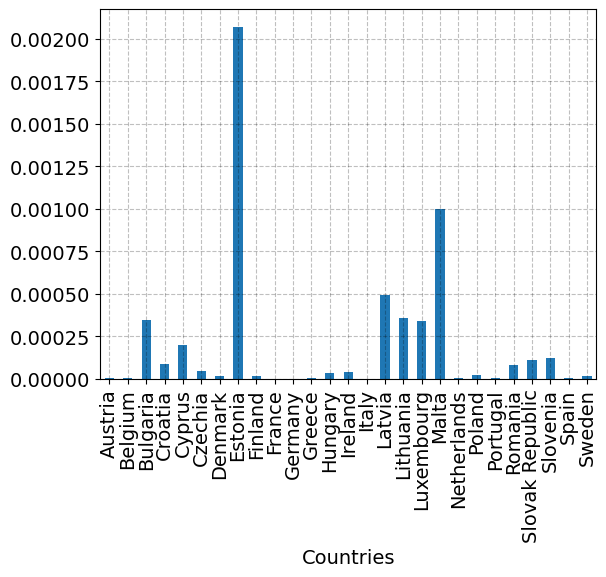

In [25]:
# plotting the gdp_growth / debt ratio
average_debt = debt_long.groupby('Countries')['debt'].mean()
average_gdp_growth = gdp_growth_long.groupby('Countries')['annual_gdp_growth'].mean()

ratio = average_gdp_growth / average_debt

ratio.plot.bar()

/var/folders/lp/437mv5sn2m10gm5j1vk_4d200000gn/T/ipykernel_1301/4015250099.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap(colormap_name, colors_per_colormap)


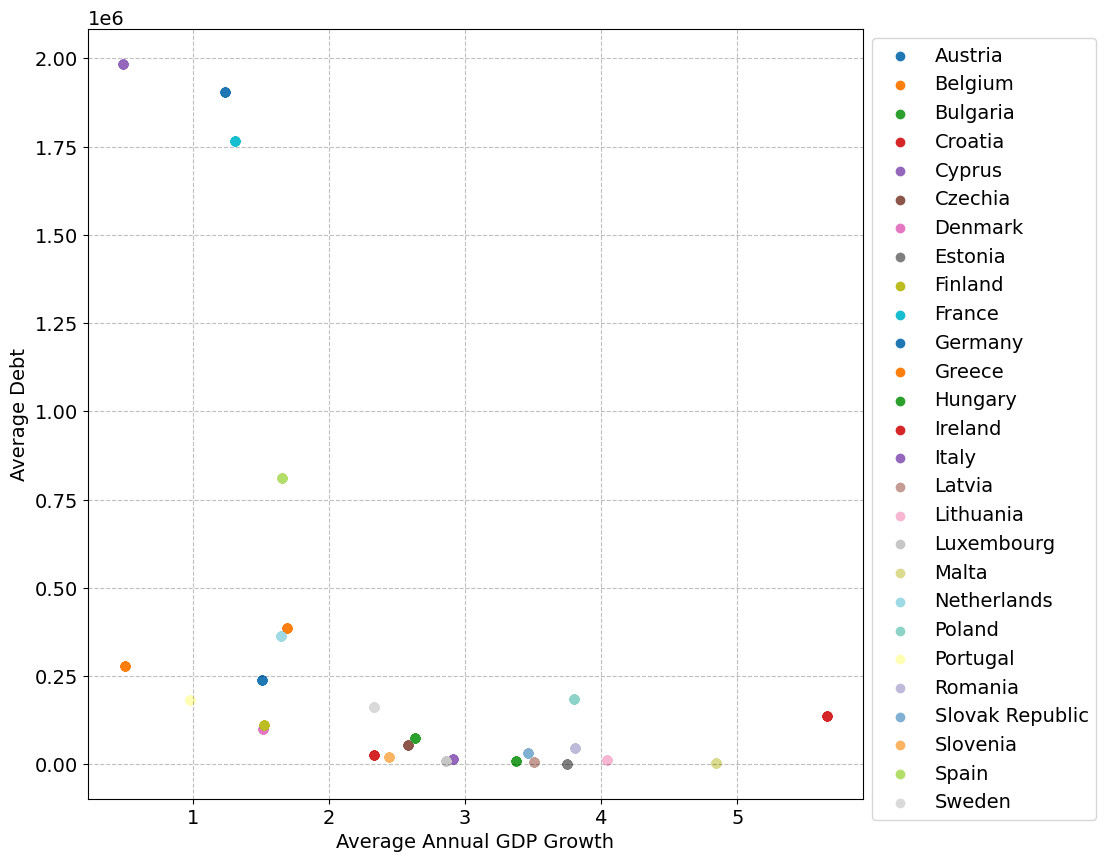

In [26]:
# Determine the number of unique countries
num_countries = len(gdp_debt_merge['Countries'].unique())

# Choose colormaps with distinct colors
colormap_names = ['tab10', 'tab20', 'Set3']
colors_per_colormap = num_countries // len(colormap_names) + 1

# Concatenate multiple colormaps to get more unique colors
colors = []
for colormap_name in colormap_names:
    colormap = plt.cm.get_cmap(colormap_name, colors_per_colormap)
    for i in range(colors_per_colormap):
        colors.append(colormap(i))

# Create a scatter plot
fig = plt.figure(frameon=True, figsize=(10, 10), dpi=100)
ax_A = fig.add_subplot(1, 1, 1)

# Set labels
ax_A.set_xlabel("Average Annual GDP Growth")
ax_A.set_ylabel("Average Debt")

# Iterate over each country's data and plot them separately with different colors
for i, (country, data) in enumerate(gdp_debt_merge.groupby('Countries')):
    ax_A.scatter(data['country_mean_gdp_growth'], data['country_mean_debt'], label=country, color=colors[i])

# Add legend
ax_A.legend(bbox_to_anchor=(1, 1))

# Show the plot
plt.show()


# Conclusion

ADD CONCISE CONLUSION.